In [1]:
import fnmatch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, *_ = rat_lists
root = r"d:\Thesis\ALLDATA"
sequence = {}
for index, animal in enumerate(intact_rats):
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal, session, name="sequence.p")

alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))
ex_alpha_0, ex_alpha_t, ex_alpha_u, ex_gamma_0, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
ex_mu_0, ex_mu_t, ex_mu_u, ex_sigma_0, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

PLOT_PARAMS = {
    'alpha_u':  dict(fit=alpha_u, ex_fit=ex_alpha_u, yticks=GENERAL_PLOT_PARAMS['alpha_u']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['alpha_u']['ylabel'],start='med', end=2),
    'gamma_u':  dict(fit=gamma_u, ex_fit=ex_gamma_u, yticks=GENERAL_PLOT_PARAMS['gamma_u']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['gamma_u']['ylabel'], start='med', end=-.15),
    'mu_u':     dict(fit=mu_u, ex_fit=ex_mu_u, yticks=GENERAL_PLOT_PARAMS['mu_u']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['mu_u']['ylabel'], start='med', end='med'),
    'sigma_u':  dict(fit=sigma_u, ex_fit=ex_sigma_u, yticks=GENERAL_PLOT_PARAMS['sigma_u']['yticks_I'], ylabel=GENERAL_PLOT_PARAMS['sigma_u']['ylabel'], start='med', end=0.04),
}
YTICKS_STATS = {
    'alpha_u': dict(slope = [-0.2, -0.1, 0, 0.1, 0.2], intercept = [0, 0.5, 1, 1.5, 2]),
    'gamma_u': dict(slope = [-0.05, -0.025, 0, 0.025, 0.05], intercept = [0, .05, .1, .15, .2, .25, .3]),
    'mu_u': dict(slope=[-.16, -.08, 0, .08, .16], intercept=[0, .3, .6, .9, 1.2]),
    'sigma_u': dict(slope=[-0.02, -.01, 0, 0.01, 0.02], intercept=[-.09, -.06, -.03, 0, .03]),
    }

Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03
no pickle found RatF00_2021_07_18_10_36_33
no pickle found RatF00_2021_07_18_15_09_13
no pickle found RatF00_2021_07_19_15_25_33
no pickle found RatF00_2021_07_20_10_09_39
no pickle found RatF00_2021_07_20_15_10_08
no pickle found RatF00_2021_07_21_10_43_27
no pickle found RatF00_2021_07_21_15_19_33
no pickle found RatF00_2021_07_22_11_23_48
no pickle found RatF00_2021_07_22_16_11_45
no pickle found RatF00_2021_07_23_10_38_43
no pickle found RatF00_2021_07_23_15_04_12
no pickle found RatF00_2021_07_24_10_49_55
no pickle found RatF00_2021_07_24_15_28_05
no pickle found RatF00_2021_07_25_10_54_14
no pickle found RatF00_2021_07_25_15_38_20
no pickle found RatF00_2021_07_26_10_23_57
no pickle found RatF00_2021_07_26_15_17_06
no pickle found RatF00_2021_08_03_10_23_20
no pickle found RatF00_20

In [3]:
def regression_permutation(var, dist_or_tm='dist', varname_slope='', varname_intercept='', raisy=0,
                           animal_list=[], color='k',
                           ax_slope=None, yticks_slope=None, 
                           ax_intercept=None, y_ticks_intercept=None, num_iterations=10000):
    ''' regression with permutation test for the slope and intercept
    var: parameter to test (e.g., alpha_0)
    dist_or_tm: 'dist' or 'tm'
    varname: name of the parameter
    lesioned_animals: True or False
    raisy: y position of the p-value
    ax_slope: axes object for the slope
    yticks_slope: yticks for the slope
    ax_intercept: axes object for the intercept
    y_ticks_intercept: yticks for the intercept
    '''

    rows = []
    _ = {"60": 0, "90": 1, "120": 2, "20": 0, "10": 1, "2": 2, "rev10": 3, "rev20": 4}

    for animal in animal_list:
        if dist_or_tm == 'dist':
            conds = ["60", "90", "120"]
        elif dist_or_tm == 'tm':
            conds = ["20", "10", "2", "rev10", "rev20"]
        else:
            raise ValueError("experiment must be 'dist' or 'tm'")
        for cond in conds:
            x = float(_[cond])
            y = var[animal][cond]
            rows.append({"animal": animal, "parameter": y, "cond": x})

    df = pd.DataFrame(rows)

    x = df.cond
    y = df.parameter

    # fit with np.polyfit
    f = lambda x, *p: np.polyval(p, x)
    p, cov = curve_fit(f, x, y, [1, 1])

    # shuffle to get p-value
    observed_slope = p[0]
    observed_intercept = p[1]
    slope_sign = np.sign(observed_slope)
    num_iterations = int(num_iterations)
    shuffled_slopes = []
    shuffled_intercepts = []

    np.random.seed(0)
    for _ in range(num_iterations):
        shuffled_y = np.random.permutation(y)
        shuffled_res, _ = curve_fit(f, x, shuffled_y, [1, 1])
        shuffled_slopes.append(shuffled_res[0])
        shuffled_intercepts.append(shuffled_res[1])

    # calculate the p-value
    p_value_slope = (np.abs(shuffled_slopes) >= np.abs(observed_slope)).mean()
    if observed_intercept >= 0:
        p_value_intercept = (np.asarray(shuffled_intercepts) <= 0).mean()
    else:
        p_value_intercept = (np.asarray(shuffled_intercepts) >= 0).mean()

    # compute r
    # y_mean = np.mean(y)
    # y_pred = f(x, *p)
    # ss_total = np.sum((y - y_mean) ** 2)
    # ss_res = np.sum((y - y_pred) ** 2)
    # r_squared = 1 - (ss_res / ss_total)
    # r = np.sqrt(r_squared)

    print(f'p_s={p_value_slope:.3f}, p_i={p_value_intercept:.3f}, obs_slope={observed_slope:.3f}, obs_intercept={observed_intercept:.3f}')
    plot_shuffling(shuffles=shuffled_slopes, pval=p_value_slope, observed=observed_slope, yticks=yticks_slope, ylabel=varname_slope, ax=ax_slope, color=color, raisy=raisy)
    if ax_intercept is not None:
        plot_shuffling(shuffles=shuffled_intercepts, pval=p_value_intercept, observed=observed_intercept, show_zero=True, yticks=y_ticks_intercept, ylabel=varname_intercept, ax=ax_intercept, color=color)

def Figure_stats(var, varname, dist_or_tm='dist', ax_slope=None, ax_intercept=None, intact=intact_rats):
    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    mediandata = {animal: {cond: np.median(var[animal][cond]) for cond in conds} for animal in intact}
    regression_permutation(mediandata, dist_or_tm=dist_or_tm, animal_list=intact_rats, color='gray',
                           varname_slope='slope',
                           varname_intercept='intercept',
                        ax_slope=ax_slope, yticks_slope=YTICKS_STATS[varname]['slope'],
                        ax_intercept=ax_intercept, y_ticks_intercept=YTICKS_STATS[varname]['intercept'])


Figure version 1 : All the U params are separated

p_s=0.402, p_i=0.288, obs_slope=0.015, obs_intercept=-0.025
p_s=0.725, p_i=0.000, obs_slope=0.005, obs_intercept=-0.164
p_s=0.527, p_i=0.303, obs_slope=-0.004, obs_intercept=0.007
p_s=0.103, p_i=0.000, obs_slope=0.004, obs_intercept=0.020
p_s=0.925, p_i=0.000, obs_slope=-0.001, obs_intercept=-0.102
p_s=0.871, p_i=0.000, obs_slope=0.001, obs_intercept=-0.180
p_s=0.590, p_i=0.672, obs_slope=-0.001, obs_intercept=0.000
p_s=0.058, p_i=0.000, obs_slope=0.002, obs_intercept=0.020


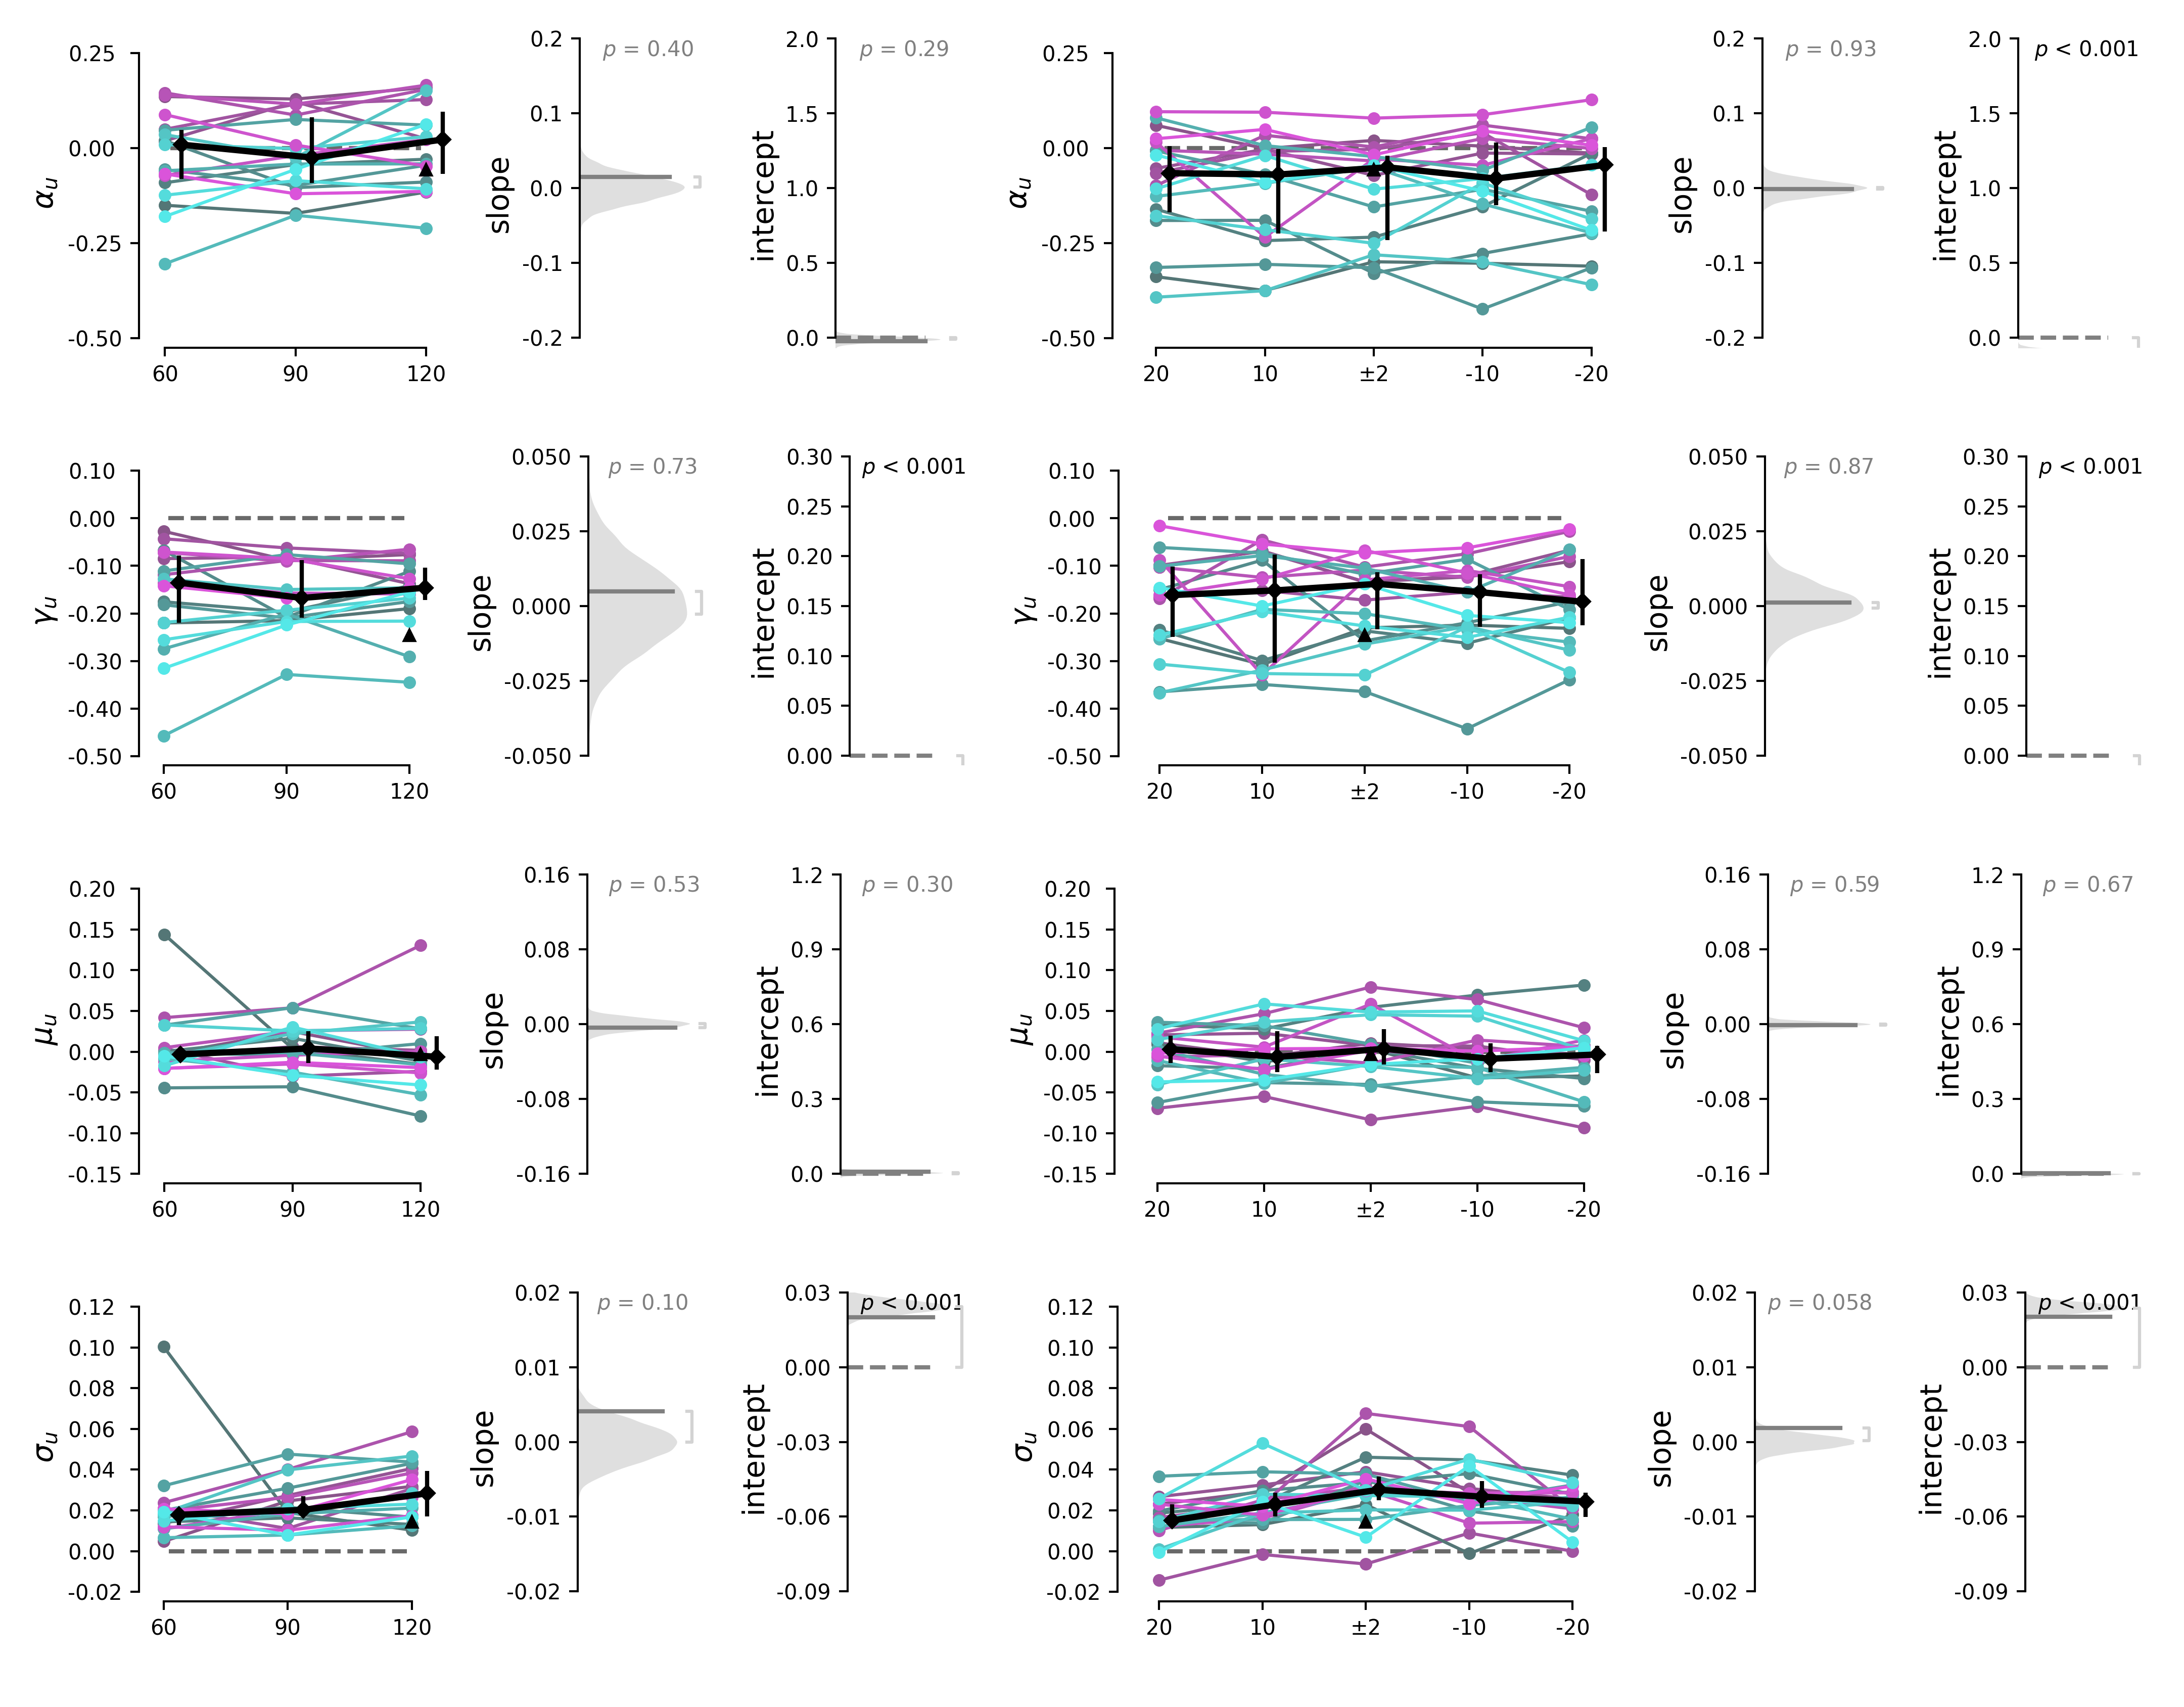

In [4]:
fig = plt.figure(figsize=(cm2inch(18), cm2inch(14)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.01
width_ratios = [3, 1.3, 1.3, 5, 1.3, 1.3]
gs0 = fig.add_gridspec(4, 1)
row1 = gs0[0].subgridspec(1, 6, width_ratios=width_ratios, wspace=0)
fit_alpha_u_distance = plt.subplot(row1[0])
ax_slope_alpha_u_distance = plt.subplot(row1[1])
ax_intercept_alpha_u_distance = plt.subplot(row1[2])
fit_alpha_u_vbelt = plt.subplot(row1[3])
ax_slope_alpha_u_vbelt = plt.subplot(row1[4])
ax_intercept_alpha_u_vbelt = plt.subplot(row1[5])

row2 = gs0[1].subgridspec(1, 6, width_ratios=width_ratios, wspace=0)
fit_gamma_u_distance = plt.subplot(row2[0])
ax_slope_gamma_u_distance = plt.subplot(row2[1])
ax_intercept_gamma_u_distance = plt.subplot(row2[2])
fit_gamma_u_vbelt = plt.subplot(row2[3])
ax_slope_gamma_u_vbelt = plt.subplot(row2[4])
ax_intercept_gamma_u_vbelt = plt.subplot(row2[5])

row3 = gs0[2].subgridspec(1, 6, width_ratios=width_ratios, wspace=0)
fit_mu_u_distance = plt.subplot(row3[0])
ax_slope_mu_u_distance = plt.subplot(row3[1])
ax_intercept_mu_u_distance = plt.subplot(row3[2])
fit_mu_u_vbelt = plt.subplot(row3[3])
ax_slope_mu_u_vbelt = plt.subplot(row3[4])
ax_intercept_mu_u_vbelt = plt.subplot(row3[5])

row4 = gs0[3].subgridspec(1, 6, width_ratios=width_ratios, wspace=0)
fit_sigma_u_distance = plt.subplot(row4[0])
ax_slope_sigma_u_distance = plt.subplot(row4[1])
ax_intercept_sigma_u_distance = plt.subplot(row4[2])
fit_sigma_u_vbelt = plt.subplot(row4[3])
ax_slope_sigma_u_vbelt = plt.subplot(row4[4])
ax_intercept_sigma_u_vbelt = plt.subplot(row4[5])

plot_model_parameter(PLOT_PARAMS['alpha_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_u_distance, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['gamma_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_u_distance, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['mu_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_u_distance, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['sigma_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_u_distance, animal_list=intact_rats, show_ylabel=True)

Figure_stats(var=alpha_u, varname='alpha_u', dist_or_tm='dist', ax_slope=ax_slope_alpha_u_distance, ax_intercept=ax_intercept_alpha_u_distance)
Figure_stats(var=gamma_u, varname='gamma_u', dist_or_tm='dist', ax_slope=ax_slope_gamma_u_distance, ax_intercept=ax_intercept_gamma_u_distance)
Figure_stats(var=mu_u, varname='mu_u', dist_or_tm='dist', ax_slope=ax_slope_mu_u_distance, ax_intercept=ax_intercept_mu_u_distance)
Figure_stats(var=sigma_u, varname='sigma_u', dist_or_tm='dist', ax_slope=ax_slope_sigma_u_distance, ax_intercept=ax_intercept_sigma_u_distance)

plot_model_parameter(PLOT_PARAMS['alpha_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_alpha_u_vbelt, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['gamma_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_gamma_u_vbelt, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['mu_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_mu_u_vbelt, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['sigma_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_sigma_u_vbelt, animal_list=intact_rats, show_ylabel=True)

Figure_stats(var=alpha_u, varname='alpha_u', dist_or_tm='tm', ax_slope=ax_slope_alpha_u_vbelt, ax_intercept=ax_intercept_alpha_u_vbelt)
Figure_stats(var=gamma_u, varname='gamma_u', dist_or_tm='tm', ax_slope=ax_slope_gamma_u_vbelt, ax_intercept=ax_intercept_gamma_u_vbelt)
Figure_stats(var=mu_u, varname='mu_u', dist_or_tm='tm', ax_slope=ax_slope_mu_u_vbelt, ax_intercept=ax_intercept_mu_u_vbelt)
Figure_stats(var=sigma_u, varname='sigma_u', dist_or_tm='tm', ax_slope=ax_slope_sigma_u_vbelt, ax_intercept=ax_intercept_sigma_u_vbelt)

Figure version 2 : The slope and intectept are kept with the other parameters and only the data are shown separately

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied.  At least one axes collapsed to zero width or height.
  fig.canvas.print_figure(bytes_io, **kw)


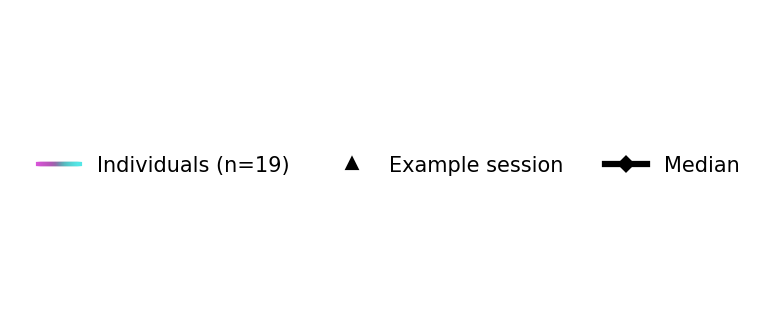

In [5]:
def dummy_legend(ax=None, animal_list=intact_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ex_session = ax.plot(2, 0, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    median = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median', zorder=5)

    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

    add_colored_intact(ax, handles=[ex_session, median], ncol=4,
                    labels=['Example session', 'Median', 'Prediction'], text=f'Individuals (n={len(animal_list)})', 
                    loc='center', bbox=(.5, .5))


fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

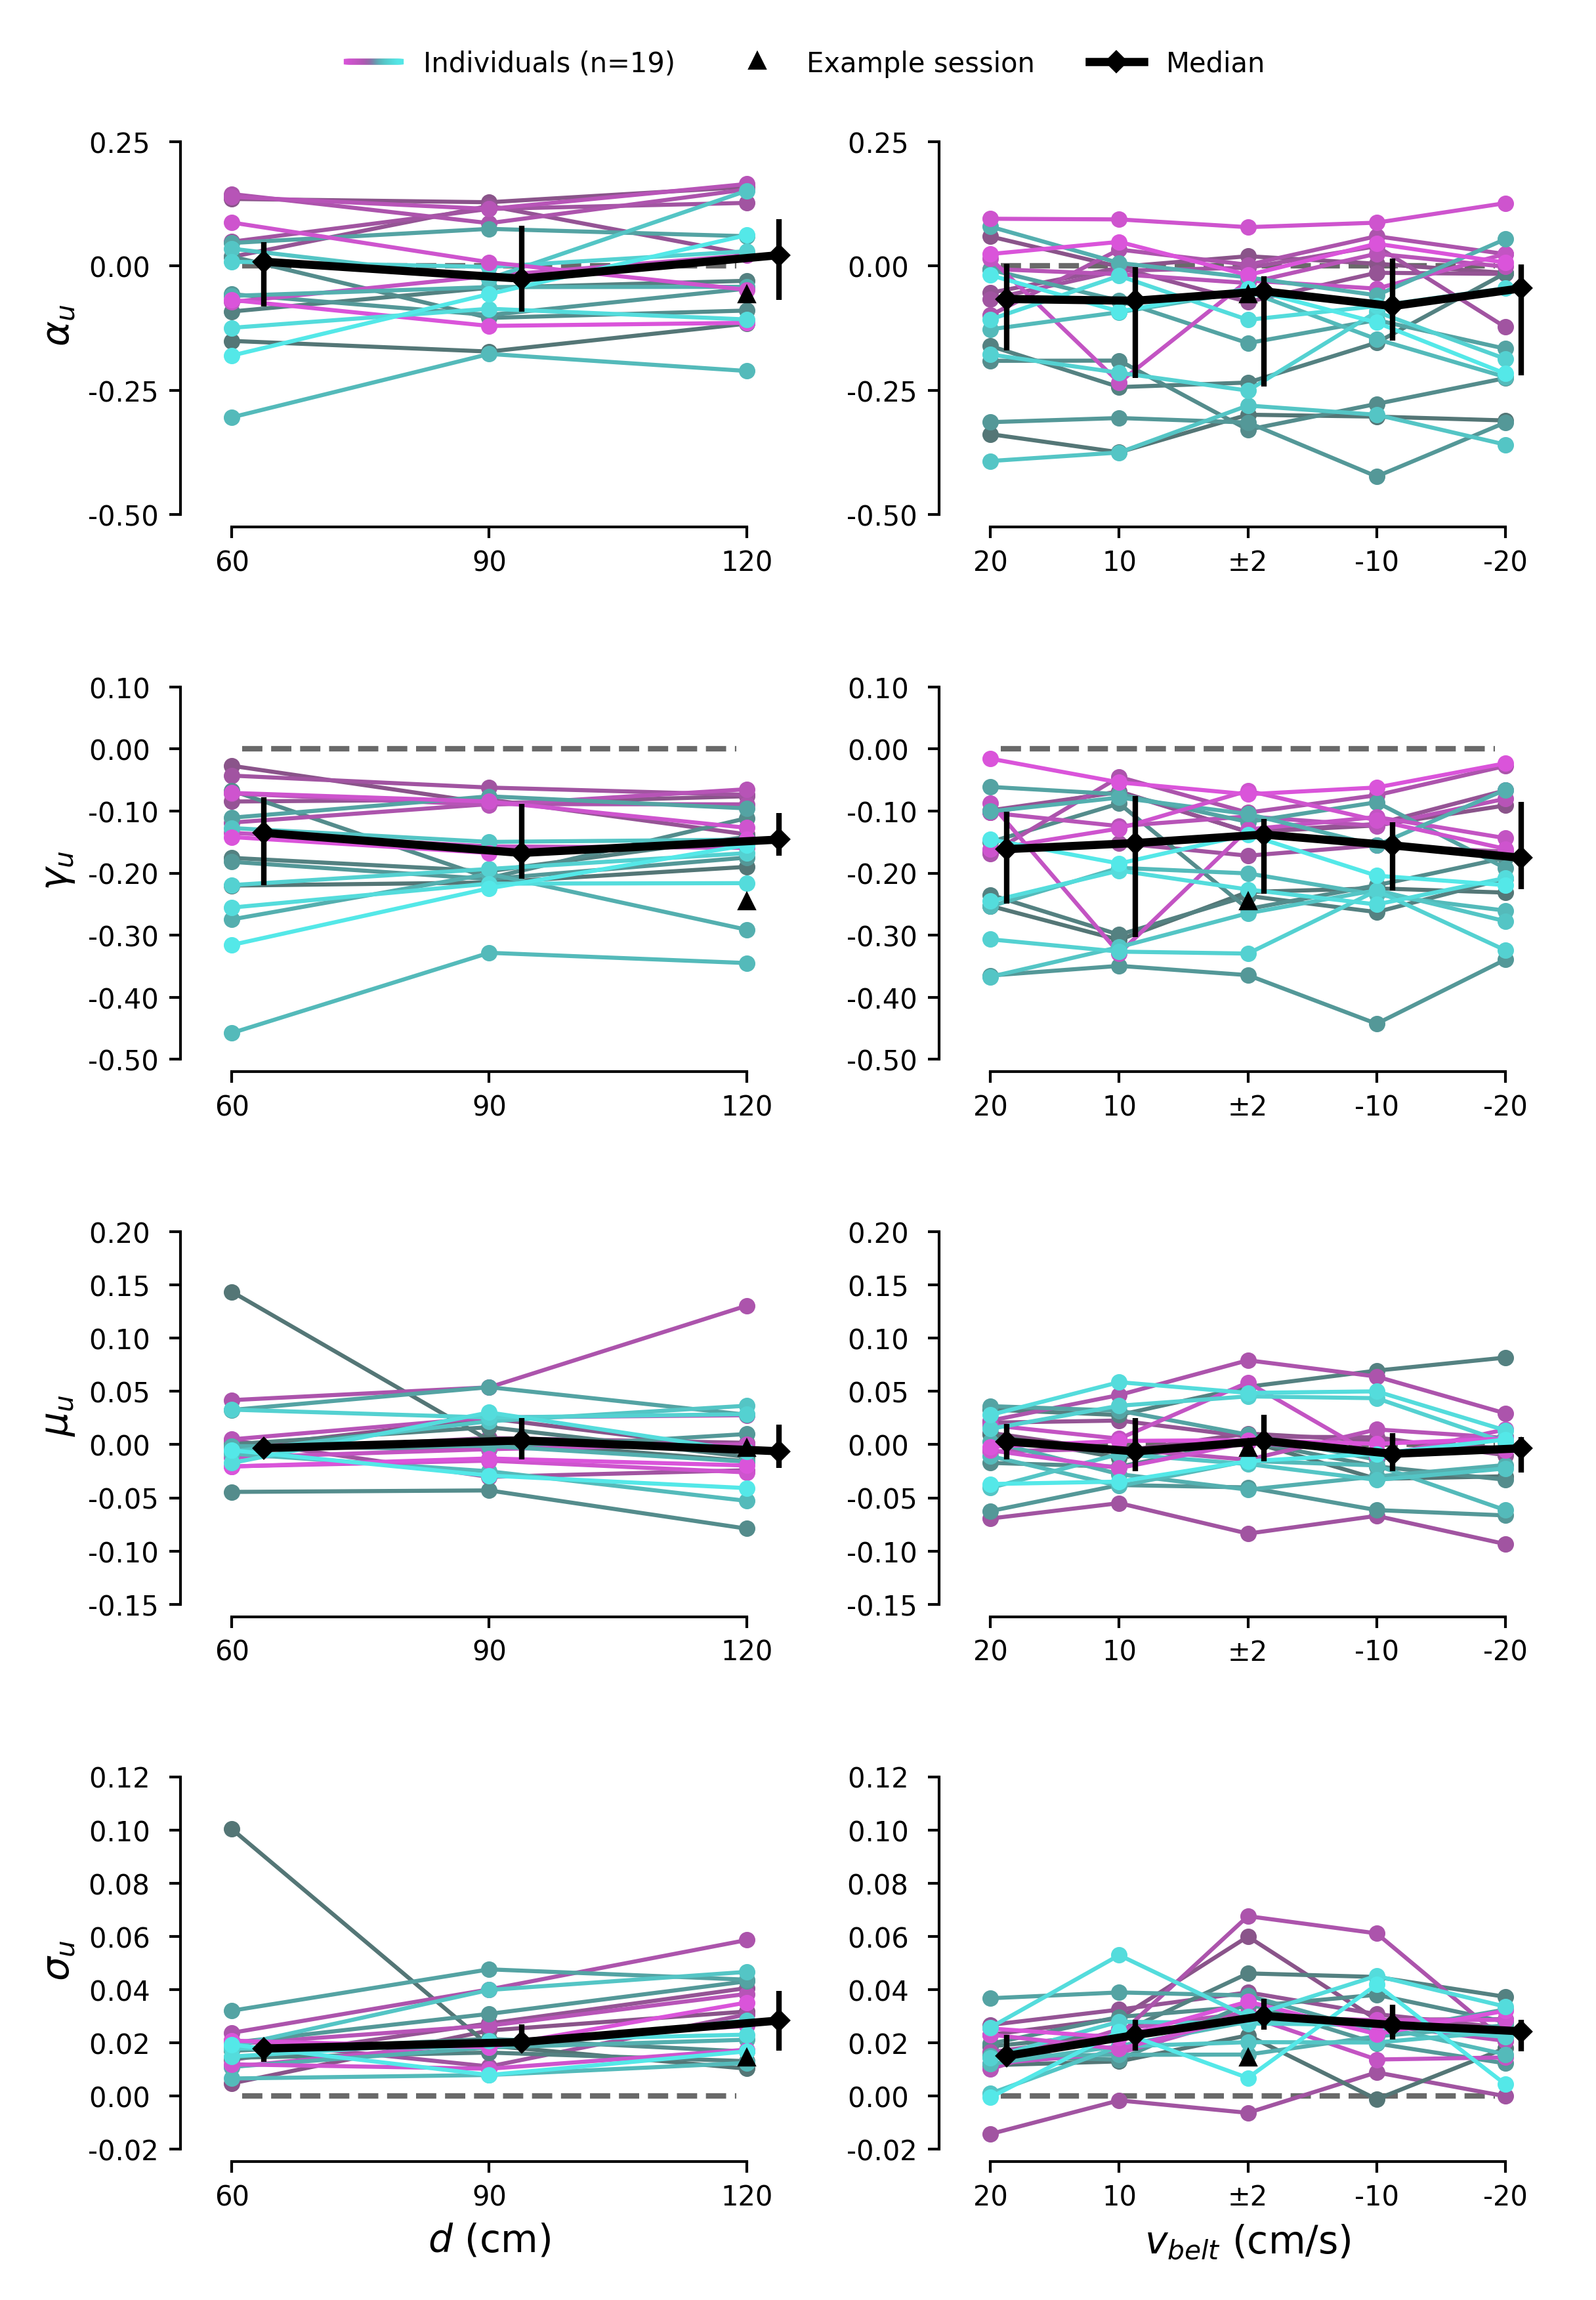

In [6]:
fig = plt.figure(figsize=(cm2inch(10), cm2inch(14)),
                #  constrained_layout=True,
                 facecolor='w', dpi=600)

pad = 0.01
width_ratios = [3, 5]
gs0 = fig.add_gridspec(4, 2)
fit_alpha_u_distance = plt.subplot(gs0[0, 0])
fit_alpha_u_vbelt = plt.subplot(gs0[0, 1])
fit_gamma_u_distance = plt.subplot(gs0[1, 0])
fit_gamma_u_vbelt = plt.subplot(gs0[1, 1])
fit_mu_u_distance = plt.subplot(gs0[2, 0])
fit_mu_u_vbelt = plt.subplot(gs0[2, 1])
fit_sigma_u_distance = plt.subplot(gs0[3, 0])
fit_sigma_u_vbelt = plt.subplot(gs0[3, 1])

plot_model_parameter(PLOT_PARAMS['alpha_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_alpha_u_distance, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['gamma_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_gamma_u_distance, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['mu_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_mu_u_distance, animal_list=intact_rats, show_ylabel=True)
plot_model_parameter(PLOT_PARAMS['sigma_u'], rat_markers, dist_or_tm='dist', show_ex=True, ax=fit_sigma_u_distance, animal_list=intact_rats, show_ylabel=True, show_xlabel=True)

plot_model_parameter(PLOT_PARAMS['alpha_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_alpha_u_vbelt, animal_list=intact_rats, show_ylabel=False)
plot_model_parameter(PLOT_PARAMS['gamma_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_gamma_u_vbelt, animal_list=intact_rats, show_ylabel=False)
plot_model_parameter(PLOT_PARAMS['mu_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_mu_u_vbelt, animal_list=intact_rats, show_ylabel=False)
plot_model_parameter(PLOT_PARAMS['sigma_u'], rat_markers, dist_or_tm='tm', show_ex=True, ax=fit_sigma_u_vbelt, animal_list=intact_rats, show_ylabel=False, show_xlabel=True)

legend = fig.add_axes([.5, 1.015, .01, .01])
dummy_legend(ax=legend)